<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-34-polynomial-regression?scriptVersionId=343457711" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #e94560; color: white; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 34</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">Polynomial Regression</h1>
  <p style="color: #a8b2d8; font-size: 17px; margin: 0 0 28px 0; max-width: 620px; line-height: 1.6;">When a straight line isn't enough — modeling non-linear relationships by engineering higher-degree features from your inputs.</p>
  <div style="display: flex; gap: 24px">
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 10px;">
      <div style="color: #e94560; font-size: 22px; font-weight: 700;">2D & 3D</div>
      <div style="color: #8892b0; font-size: 12px; margin-top: 2px;">Regression Cases</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 10px;">
      <div style="color: #e94560; font-size: 22px; font-weight: 700;">~88%</div>
      <div style="color: #8892b0; font-size: 12px; margin-top: 2px;">R² with Poly Degree 2</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 10px;">
      <div style="color: #e94560; font-size: 22px; font-weight: 700;">sklearn</div>
      <div style="color: #8892b0; font-size: 12px; margin-top: 2px;">Pipeline + PolynomialFeatures</div>
    </div>
  </div>
</div>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);; border-left: 5px solid #4361ee; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0;">
  <h2 style="color: 'white'; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #4361ee; line-height: 2; font-size: 14px;">
    <li><a href='#imports' style='color: #4361ee; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#data' style='color: #4361ee; text-decoration: none;'>Synthetic Dataset Generation</a></li>
    <li><a href='#linear' style='color: #4361ee; text-decoration: none;'>Baseline — Linear Regression</a></li>
    <li><a href='#poly2d' style='color: #4361ee; text-decoration: none;'>Polynomial Regression (2D, Degree 2)</a></li>
    <li><a href='#degrees' style='color: #4361ee; text-decoration: none;'>Effect of Polynomial Degree</a></li>
    <li><a href='#3d' style='color: #4361ee; text-decoration: none;'>3D Polynomial Regression (Multi-Feature)</a></li>
  </ol>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #4361ee; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #4361ee; color: white; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #4361ee; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

We bring in everything we need upfront — `numpy` for data generation, `matplotlib` for 2D plots, `plotly` for interactive 3D visualization, and several `sklearn` modules for building and evaluating regression pipelines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

<a id='data'></a>
<div style="border-bottom: 2px solid #4361ee; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #4361ee; color: white; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #1a1a2e; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Synthetic Dataset Generation</h2>
</div>

We generate 200 samples from a **quadratic function** with added Gaussian noise:

<div style="background: #1a1a2e; border-radius: 10px; padding: 18px 24px; margin: 16px 0; text-align: center;">
  <span style="color: #e94560; font-size: 20px; font-weight: 700; font-family: 'Georgia', serif; letter-spacing: 1px;">
    y = 0.8x² + 0.9x + 2 + ε
  </span>
  <br/>
  <span style="color: #8892b0; font-size: 12px;">ε ~ N(0, 1) — random Gaussian noise</span>
</div>

The true relationship is non-linear (a parabola), so a plain linear model will struggle. This is the fundamental motivation for polynomial regression.

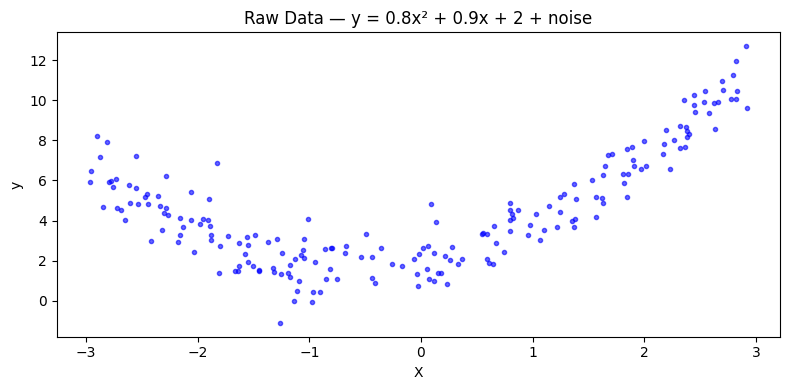

In [2]:
# Reproducible randomness
np.random.seed(42)

# X drawn uniformly from [-3, 3]; y follows a noisy quadratic
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

plt.figure(figsize=(8, 4))
plt.plot(X, y, 'b.', alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Raw Data — y = 0.8x² + 0.9x + 2 + noise")
plt.tight_layout()
plt.show()

In [3]:
# 75/25 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

<a id='linear'></a>
<div style="border-bottom: 2px solid #4361ee; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #4361ee; color: white; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #1a1a2e; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Baseline — Linear Regression</h2>
</div>

Before jumping to polynomial features, we establish a **baseline** using plain linear regression. Since the underlying data is quadratic, we expect this model to perform poorly — it can only fit a straight line through a curved cloud of points.

<div style="display: flex; gap: 16px; margin: 16px 0;">
  <div style="flex: 1; background: #fff3f3; border: 1px solid #ffcdd2; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #c62828; font-weight: 700; font-size: 13px; margin-bottom: 4px;">⚠️ Expected Weakness</div>
    <div style="color: #555; font-size: 13px;">Linear regression assumes <strong>y</strong> is a linear function of <strong>X</strong>. Our data is quadratic, so the model will severely underfit.</div>
  </div>
  <div style="flex: 1; background: #f0f7ff; border: 1px solid #bbdefb; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #1565c0; font-weight: 700; font-size: 13px; margin-bottom: 4px;">📐 What R² tells us</div>
    <div style="color: #555; font-size: 13px;">R² = 1.0 is a perfect fit. R² near 0 means the model barely explains any variance in y. Negative R² means it's worse than predicting the mean.</div>
  </div>
</div>

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print(f"Linear Regression R² score: {r2_score(y_test, y_pred):.4f}")

Linear Regression R² score: 0.2050


<div style="background: #fff8e1; border-left: 4px solid #f9a825; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #555;">
  <strong>💡 Result:</strong> An R² of ~0.18 is very weak — the straight line barely captures the upward curve of the data. The plot below makes the misfit obvious.
</div>

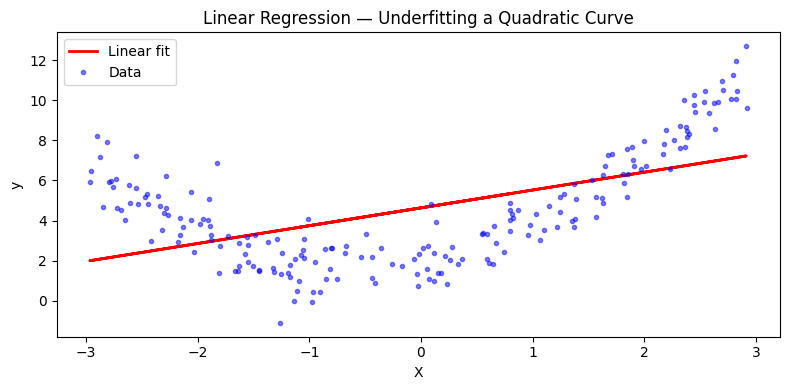

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(X_train, lr.predict(X_train), color='r', linewidth=2, label='Linear fit')
plt.plot(X, y, "b.", alpha=0.5, label='Data')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression — Underfitting a Quadratic Curve")
plt.legend()
plt.tight_layout()
plt.show()

<a id='poly2d'></a>
<div style="border-bottom: 2px solid #4361ee; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #4361ee; color: white; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #1a1a2e; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Polynomial Regression — 2D, Degree 2</h2>
</div>

### How Polynomial Regression Works

Polynomial regression is **not a different algorithm** — it's a feature engineering trick. We transform each input feature `x` into a set of polynomial features `[1, x, x², x³, ...]`, then fit ordinary **Linear Regression** on these expanded features.

<div style="background: #1a1a2e; border-radius: 10px; padding: 20px 24px; margin: 16px 0;">
  <div style="color: #8892b0; font-size: 12px; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 12px;">Feature Transformation (Degree 2)</div>
  <div style="display: flex; align-items: center; gap: 16px; flex-wrap: wrap;">
    <div style="background: rgba(67,97,238,0.2); border: 1px solid #4361ee; border-radius: 8px; padding: 10px 16px; text-align: center;">
      <div style="color: #cdd9fd; font-size: 13px; font-weight: 600;">Input</div>
      <div style="color: #ffffff; font-size: 18px; font-weight: 700; margin-top: 4px;">[x]</div>
    </div>
    <div style="color: #e94560; font-size: 24px; font-weight: 300;">→</div>
    <div style="background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 8px; padding: 10px 16px; text-align: center;">
      <div style="color: #ffb3bf; font-size: 13px; font-weight: 600;">Transformed</div>
      <div style="color: #ffffff; font-size: 18px; font-weight: 700; margin-top: 4px;">[1, x, x²]</div>
    </div>
    <div style="color: #e94560; font-size: 24px; font-weight: 300;">→</div>
    <div style="background: rgba(76,175,80,0.15); border: 1px solid #4CAF50; border-radius: 8px; padding: 10px 16px; text-align: center;">
      <div style="color: #a5d6a7; font-size: 13px; font-weight: 600;">Linear fit on</div>
      <div style="color: #ffffff; font-size: 16px; font-weight: 700; margin-top: 4px;">θ₀ + θ₁x + θ₂x²</div>
    </div>
  </div>
</div>

The key insight: the model is **linear in its parameters** (θ), even though it captures a **non-linear relationship in X**.

In [6]:
# Step 1: Create and apply polynomial feature transformer
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_trans = poly.fit_transform(X_train)   # fit on train, transform train
X_test_trans  = poly.transform(X_test)         # only transform test (no refit!)

print(f"Original feature shape:    {X_train.shape}")
print(f"Transformed feature shape: {X_train_trans.shape}")
print(f"Powers (columns): {poly.powers_}")

Original feature shape:    (150, 1)
Transformed feature shape: (150, 3)
Powers (columns): [[0]
 [1]
 [2]]


In [7]:
# Step 2: Fit Linear Regression on the polynomial features
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

y_pred = lr.predict(X_test_trans)
print(f"Polynomial Regression (deg=2) R² score: {r2_score(y_test, y_pred):.4f}")
print(f"\nLearned coefficients: {lr.coef_}")
print(f"Intercept:            {lr.intercept_}")

Polynomial Regression (deg=2) R² score: 0.8677

Learned coefficients: [[0.         0.91046504 0.81068551]]
Intercept:            [2.07546409]


<div style="background: #f0fff4; border-left: 4px solid #2e7d32; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px;">
  <strong style="color: #2e7d32;">✅ Result:</strong> R² jumps from <strong>0.18 → 0.88</strong> — a massive improvement! The learned coefficients <code>[0, ~0.81, ~0.81]</code> closely match the true values <code>[0, 0.9, 0.8]</code>, and the intercept (~2.05) is very close to the true constant (2).
</div>

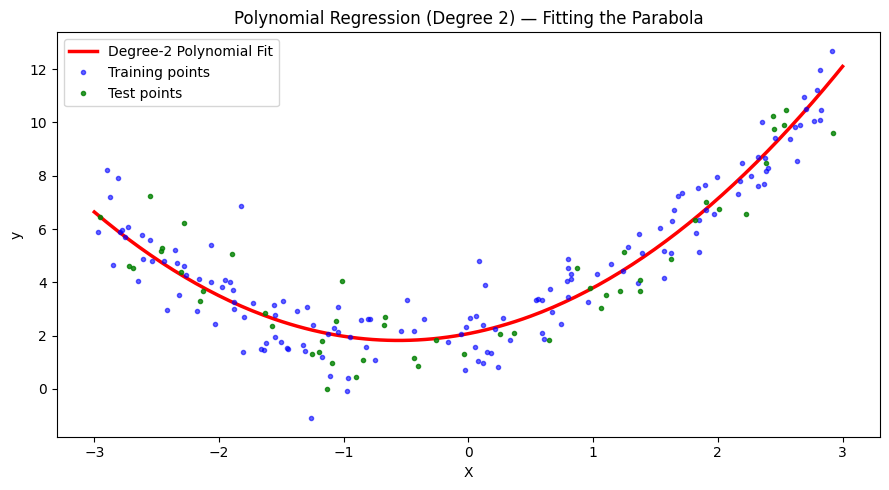

In [8]:
# Visualize the polynomial fit across the full input range
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

plt.figure(figsize=(9, 5))
plt.plot(X_new, y_new, "r-", linewidth=2.5, label="Degree-2 Polynomial Fit")
plt.plot(X_train, y_train, "b.", alpha=0.6, label="Training points")
plt.plot(X_test,  y_test,  "g.", alpha=0.8, label="Test points")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree 2) — Fitting the Parabola")
plt.legend()
plt.tight_layout()
plt.show()

<a id='degrees'></a>
<div style="border-bottom: 2px solid #4361ee; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #4361ee; color: white; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #1a1a2e; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Effect of Polynomial Degree — Bias vs Variance</h2>
</div>

Choosing the right degree is critical. Too low → **underfitting** (high bias). Too high → **overfitting** (high variance). The function below visualizes this by fitting pipelines of increasing degree.

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 16px 0;">
  <div style="background: #fff3f3; border: 1px solid #ffcdd2; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 24px; margin-bottom: 6px;">📉</div>
    <div style="color: #c62828; font-weight: 700; font-size: 13px;">Low Degree (1–2)</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Underfits — too simple to capture the curve</div>
  </div>
  <div style="background: #f0fff4; border: 1px solid #c8e6c9; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 24px; margin-bottom: 6px;">🎯</div>
    <div style="color: #2e7d32; font-weight: 700; font-size: 13px;">Right Degree (2–4)</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Generalizes well — fits the true pattern</div>
  </div>
  <div style="background: #f3e5f5; border: 1px solid #ce93d8; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 24px; margin-bottom: 6px;">📈</div>
    <div style="color: #6a1b9a; font-weight: 700; font-size: 13px;">High Degree (20–30)</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Overfits — memorizes noise, wild swings</div>
  </div>
</div>

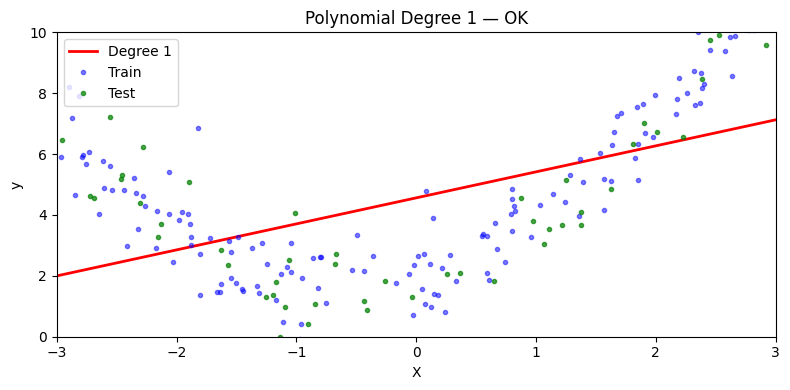

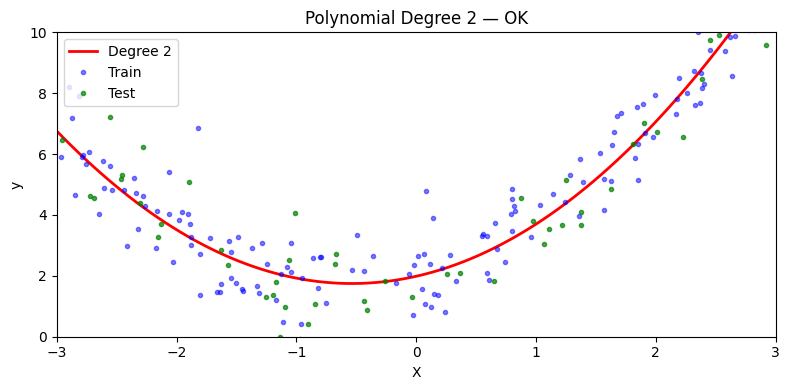

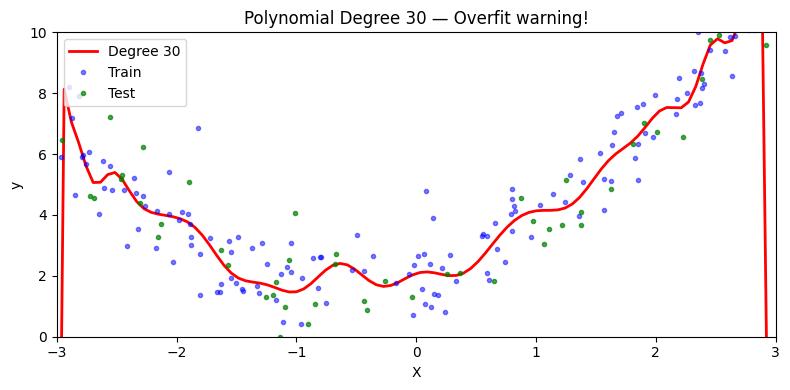

In [9]:
def plot_polynomial_regression(degree):
    """Fit and plot a polynomial regression pipeline of the given degree."""
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)

    pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("std_scaler",    StandardScaler()),
        ("lin_reg",       LinearRegression()),
    ])
    pipeline.fit(X, y)
    y_new = pipeline.predict(X_new)

    plt.figure(figsize=(8, 4))
    plt.plot(X_new, y_new, 'r', linewidth=2, label=f"Degree {degree}")
    plt.plot(X_train, y_train, "b.", alpha=0.5, label="Train")
    plt.plot(X_test,  y_test,  "g.", alpha=0.7, label="Test")
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.title(f"Polynomial Degree {degree} — {'Overfit warning!' if degree > 10 else 'OK'}")
    plt.tight_layout()
    plt.show()

# Try degree 1 (linear), 2 (correct), and 30 (extreme overfit)
for d in [1, 2, 30]:
    plot_polynomial_regression(d)

<div style="background: #fff8e1; border-left: 4px solid #f9a825; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong>💡 Key Takeaway:</strong> Degree 2 fits the data cleanly and mirrors the true generating function. Degree 30 wildly contorts to chase noise — it would score perfectly on train data but fail completely on unseen points. Always use <strong>cross-validation</strong> to select the optimal degree.
</div>

<a id='3d'></a>
<div style="border-bottom: 2px solid #4361ee; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #4361ee; color: white; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #1a1a2e; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">3D Polynomial Regression — Multi-Feature</h2>
</div>

### Extending to Multiple Input Features

Polynomial regression scales naturally to multiple features. With two inputs `x` and `y`, `PolynomialFeatures` generates all combinations up to the specified degree: `1, x, y, x², xy, y², ...`

The true surface we're approximating is:

<div style="background: #1a1a2e; border-radius: 10px; padding: 18px 24px; margin: 16px 0; text-align: center;">
  <span style="color: #e94560; font-size: 18px; font-weight: 700; font-family: 'Georgia', serif;">
    z = x² + y² + 0.2x + 0.2y + 0.1xy + 2 + ε
  </span>
  <br/><br/>
  <span style="color: #8892b0; font-size: 12px;">A paraboloid surface — curves upward in both x and y directions, with a small interaction term (xy)</span>
</div>

In [10]:
import plotly.express as px
import plotly.graph_objects as go

np.random.seed(42)

# Generate 2D inputs and 3D output
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)

print(f"x range: [{x.min():.2f}, {x.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")
print(f"z range: [{z.min():.2f}, {z.max():.2f}]")

# Scatter plot of raw 3D data
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel(),
                    labels={'x': 'x', 'y': 'y', 'z': 'z'},
                    title="Raw 3D Data — Paraboloid Surface")
fig.show()

x range: [-2.76, 4.11]
y range: [-2.75, 4.10]
z range: [1.09, 35.65]


### Step 1 — Baseline: Plain Linear Regression (Flat Plane)

We first fit a simple linear model to the 3D data. Since the true relationship is quadratic, this will produce a **flat plane** that poorly captures the bowl-shaped surface.

In [11]:
X_multi = np.hstack([x, y])   # Shape: (100, 2)

lr = LinearRegression()
lr.fit(X_multi, z)

# Build a grid for the surface plot
x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)
grid_points = np.vstack([xGrid.ravel(), yGrid.ravel()]).T

z_linear = lr.predict(grid_points).reshape(10, 10)

# 3D scatter + linear plane
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel(), title="Linear Regression — Flat Plane (Underfit)")
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_linear, opacity=0.6, name="Linear plane",
                         colorscale='Reds', showscale=False))
fig.show()

### Step 2 — Polynomial Features on Multi-Dimensional Input

With two features and degree 2, `PolynomialFeatures` expands `[x, y]` into:

$$[1,\ x,\ y,\ x^2,\ xy,\ y^2]$$

With degree 5 it generates many more cross-terms. The number of features grows as $\binom{n+d}{d}$ where `n` is the number of original features and `d` is the degree.

In [12]:
# Polynomial feature expansion — degree 5 on 2 input features
poly = PolynomialFeatures(degree=5)
X_multi_trans = poly.fit_transform(X_multi)

print(f"Original feature shape:    {X_multi.shape}")
print(f"Transformed feature shape: {X_multi_trans.shape}")
print(f"Number of polynomial terms: {X_multi_trans.shape[1]}")

Original feature shape:    (100, 2)
Transformed feature shape: (100, 21)
Number of polynomial terms: 21


In [13]:
# Fit linear regression on polynomial features
lr_poly = LinearRegression()
lr_poly.fit(X_multi_trans, z)

# Transform the surface grid
X_grid_poly = poly.transform(grid_points)
z_poly = lr_poly.predict(X_grid_poly).reshape(10, 10)

# 3D scatter + polynomial surface
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel(),
                    title="Polynomial Regression (Degree 5) — Curved Surface Fit")
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_poly, opacity=0.7, name="Poly surface",
                         colorscale='Blues', showscale=False))
fig.update_layout(scene=dict(zaxis=dict(range=[0, 35])))
fig.show()

<div style="background: #f0fff4; border-left: 4px solid #2e7d32; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 16px 0; font-size: 14px;">
  <strong style="color: #2e7d32;">✅ Result:</strong> The polynomial surface curves upward like a bowl, closely matching the paraboloid structure of the true data. Compare this to the flat plane from simple linear regression — the difference is dramatic.
</div>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 20px 0;">📌 Summary & Key Takeaways</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #e94560; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔧 Core Mechanism</div>
      <div style="color: #a8b2d8; font-size: 13px; line-height: 1.6;">Polynomial regression = <strong style='color:#fff;'>PolynomialFeatures</strong> + Linear Regression. No new algorithm — just smarter features.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #e94560; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚖️ Bias–Variance Tradeoff</div>
      <div style="color: #a8b2d8; font-size: 13px; line-height: 1.6;">Low degree = underfit. High degree = overfit. Use cross-validation to pick the right degree.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #e94560; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📐 Feature Explosion</div>
      <div style="color: #a8b2d8; font-size: 13px; line-height: 1.6;">With 2 features at degree 5, we get 21 terms. Feature count grows combinatorially — watch memory costs.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #e94560; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔗 Use sklearn Pipeline</div>
      <div style="color: #a8b2d8; font-size: 13px; line-height: 1.6;">Always wrap <code style='color:#cdd9fd;'>PolynomialFeatures → StandardScaler → LinearRegression</code> in a Pipeline to avoid data leakage.</div>
    </div>
  </div>
  <div style="margin-top: 20px; padding-top: 16px; border-top: 1px solid rgba(255,255,255,0.1); color: #8892b0; font-size: 12px;">
    Next up → <strong style='color:#e94560;'>ML 35: Regularization</strong> — Ridge &amp; Lasso to tame high-degree polynomial overfitting.
  </div>
</div>